<a href="https://colab.research.google.com/github/juliafarah/MVP_Data_Analysis/blob/main/MVP_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MVP Data Analysis**

**Aluna:** Julia Farah *(Matr.: )*

**Data:** 12/04/2026

**Dataset**: Logística Global e Gestão de Riscos (Setor de Óleo e Gás)

### **Introdução**

* **Definição e Descrição do Problema**

Em uma economia globalizada, a eficiência da cadeia de suprimentos é um fator crítico para a competitividade e sobrevivência das multinacionais. O gerenciamento de uma malha logística em escala global, que opera simultaneamente com quatro modais de transporte (Marítimo, Aéreo, Rodoviário e Ferroviário), apresenta uma altíssima complexidade. Atrasos ou interrupções nesse fluxo, frequentemente causados por fatores externos incontroláveis, podem comprometer a continuidade das operações de ponta a ponta, gerando gargalos produtivos, quebra de nível de serviço (SLA) e perdas financeiras significativas.


**Fonte:** [Kaggle](https://www.kaggle.com/datasets/nudratabbas/global-supply-chain-risk-and-logistics-2024-2026)


* **Objetivo do MVP**

Este projeto utiliza um dataset de movimentações de carga globais para identificar os principais fatores de risco e interrupção na cadeia de suprimentos. O objetivo é conduzir uma Análise Exploratória de Dados (EDA) que **avalie a vulnerabilidade** e o **tempo de entrega (Lead Time) de cada modal** frente a variáveis críticas, como instabilidade geopolítica e severidade climática. O foco é extrair insights claros para suportar a tomada de decisão estratégica da gerência, visando a mitigação de atrasos e a construção de uma operação logística mais resiliente.


* **Tipo de Aprendizado:** Supervisionado (Classificação)

* **Definição dos Atributos**

**`Shipment_ID`** : Identificador único da carga.

**`Date`** : Data de despacho da carga (2024 a 2026).

**`Origin_Port`** : Portos de origem (Hubs globais)

**`Destination_Port`** : Portos de destino (Hubs globais).

**`Transport_Mode`** : Modal (Sea, Air, Rail, Road).

**`Distance_km`** : Distância total percorrida.

**`Weight_MT`** : Peso da carga em Toneladas Métricas.

 **`Fuel_Price_Index`** : Índice de custo de combustível no despacho.

 **`Geopolitical_Risk_Score`** : Índice de risco regional (0 a 10).

 **`Weather_Condition`** : Condição climática (Clear, Storm, Hurricane, etc).

 **`Carrier_Reliability_Score`** : Score de confiabilidade do transportador (0.5 a 1.0).

**`Lead_Time_Days`** : Tempo real de entrega (Variável Alvo para Regressão).

**`Disruption_Occurred`** : Flag de interrupção ou atraso (0: Não / 1: Sim).

# **1. Pre Processamento dos Dados**

In [2]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

# Carregando o arquivo (certifique-se de que o nome está idêntico ao do arquivo subido)
df = pd.read_csv('https://raw.githubusercontent.com/juliafarah/MVP_Data_Analysis/refs/heads/main/global_supply_chain_risk_2026.csv')

# Visualizando as 5 primeiras linhas para confirmar que funcionou
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


* **Detalhes do dataset:**

In [4]:
print("Quantidade de linhas e colunas:", df.shape)

Quantidade de linhas e colunas: (5000, 14)


* **Tipo de cada coluna:**

In [5]:
# Mostra o tipo de cada coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   object 
 1   Date                       5000 non-null   object 
 2   Origin_Port                5000 non-null   object 
 3   Destination_Port           5000 non-null   object 
 4   Transport_Mode             5000 non-null   object 
 5   Product_Category           5000 non-null   object 
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   object 
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64

* **Verificação de valores nulos:**

In [6]:
df.isnull().sum()

,0
Shipment_ID,0
Date,0
Origin_Port,0
Destination_Port,0
Transport_Mode,0
Product_Category,0
Distance_km,0
Weight_MT,0
Fuel_Price_Index,0
Geopolitical_Risk_Score,0


* **Resumo estatístico:**

In [7]:
df.describe()


,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000


* **Convertendo o tipo da coluna `Date` de object para datetime**

In [8]:

df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Shipment_ID                5000 non-null   object        
 1   Date                       5000 non-null   datetime64[ns]
 2   Origin_Port                5000 non-null   object        
 3   Destination_Port           5000 non-null   object        
 4   Transport_Mode             5000 non-null   object        
 5   Product_Category           5000 non-null   object        
 6   Distance_km                5000 non-null   float64       
 7   Weight_MT                  5000 non-null   float64       
 8   Fuel_Price_Index           5000 non-null   float64       
 9   Geopolitical_Risk_Score    5000 non-null   float64       
 10  Weather_Condition          5000 non-null   object        
 11  Carrier_Reliability_Score  5000 non-null   float64       
 12  Lead_T

*   **Definindo colunas por tipo (numericas e categoricas)**


In [9]:
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
colunas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f"Atributos Numéricos: {colunas_numericas}\n")
print(f"Atributos Categóricos: {colunas_categoricas}")

Atributos Numéricos: ['Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred']

Atributos Categóricos: ['Shipment_ID', 'Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Weather_Condition']


* **Verificação manual de inconsistências comuns em Supply Chain:**


In [31]:
inconsistencias = df[(df['Lead_Time_Days'] <= 0) | (df['Distance_km'] <= 0)].shape[0]
print(f"\nInconsistências detectadas (LT<0 & Dist<0): {inconsistencias}")S


Inconsistências detectadas (LT<0 & Dist<0): 0


* **Tipo de distribuição de cada atributo numéricos:**

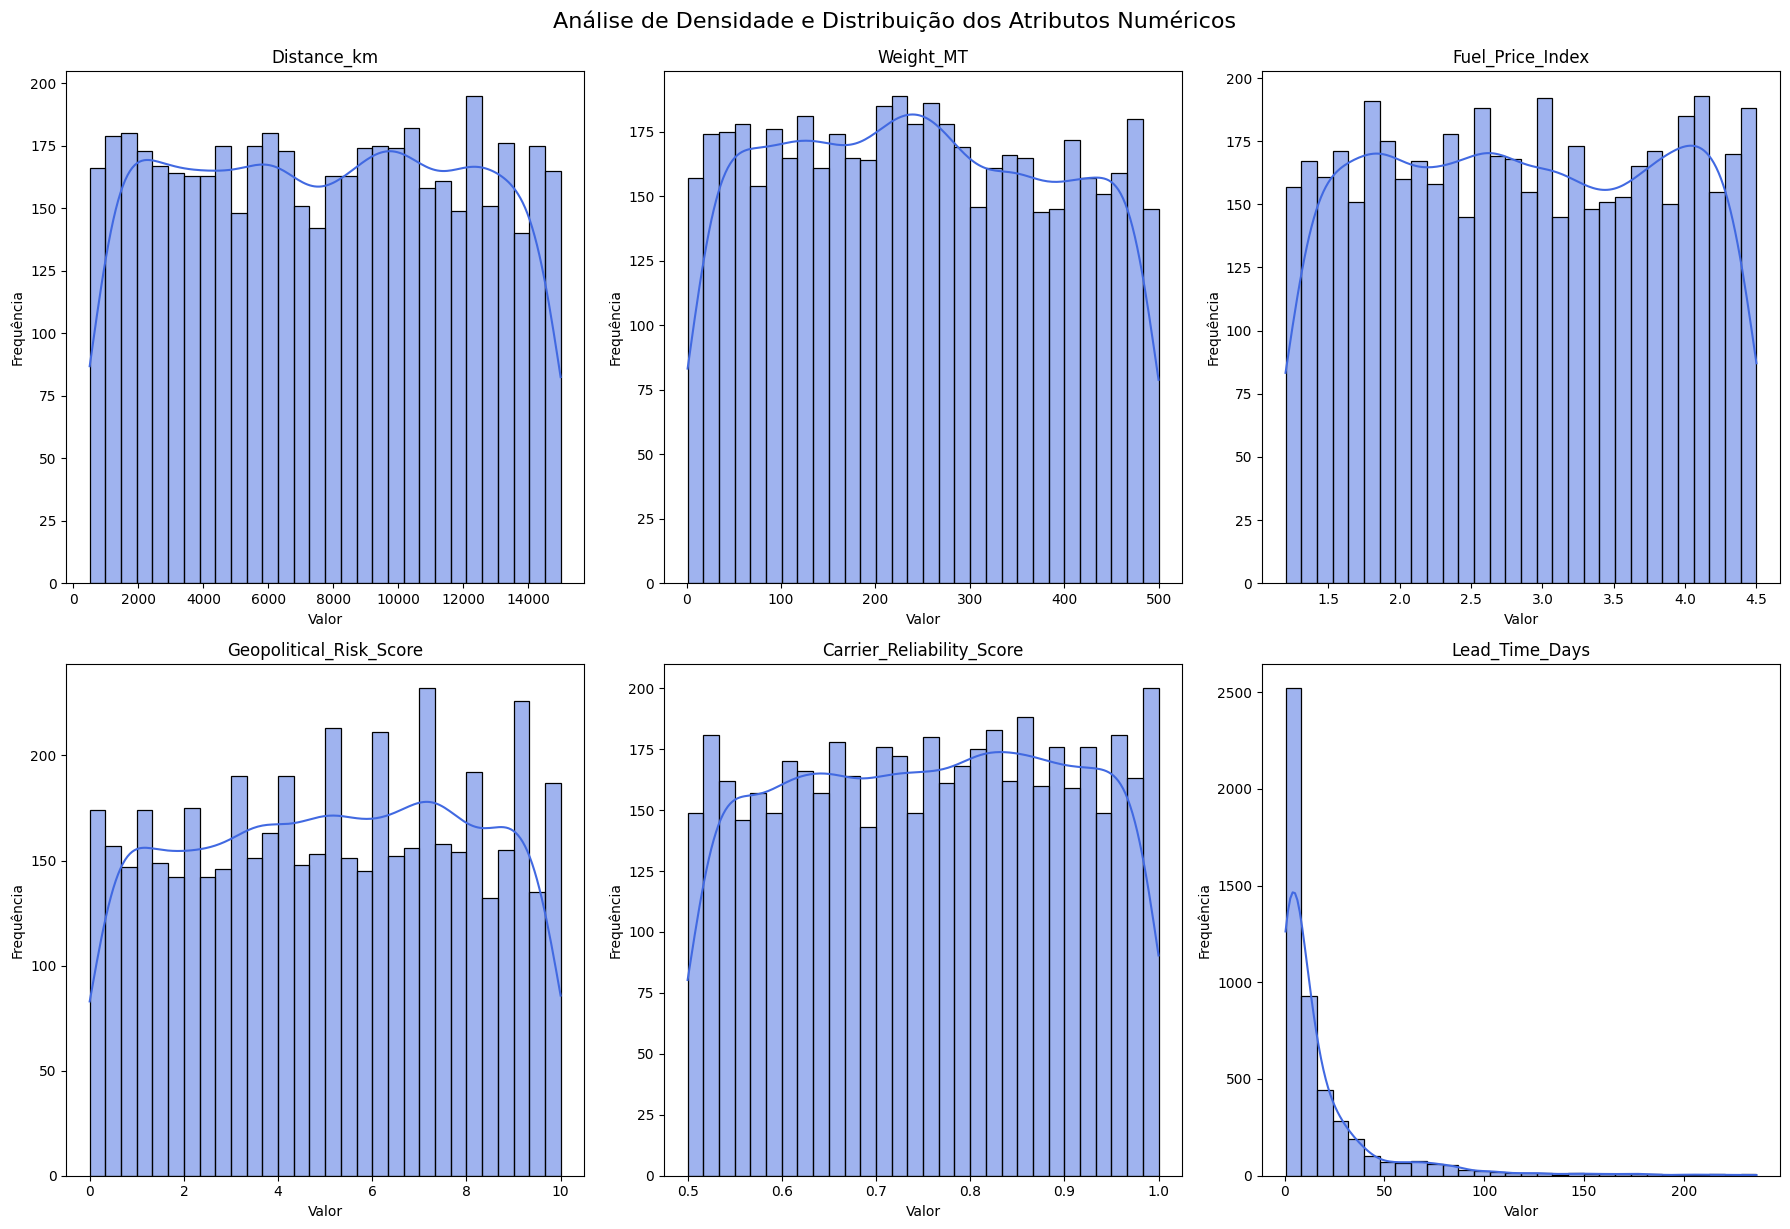

In [11]:
plt.figure(figsize=(18, 12))


cols_to_plot = ['Distance_km', 'Weight_MT', 'Fuel_Price_Index',
                'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Lead_Time_Days']

for i, col in enumerate(cols_to_plot):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, color='royalblue', bins=30)
    plt.title(col)
    plt.xlabel('Valor')
    plt.ylabel('Frequência')

plt.tight_layout()
plt.suptitle('Análise de Densidade e Distribuição dos Atributos Numéricos', fontsize=16, y=1.02)
plt.show()

**Insights relevantes:**

A visualização das distribuições mostra que a maioria dos atributos (como Risco Geopolítico e Distância) segue uma Distribuição Uniforme, garantindo que o modelo seja treinado em uma gama variada de situações sem sobreposição de classes. Entretanto, o `Lead_Time_Days` exibe uma Distribuição Exponencial/Log-normal, concentrada em valores baixos, mas com uma cauda longa.

* **Matriz de Correlação:**


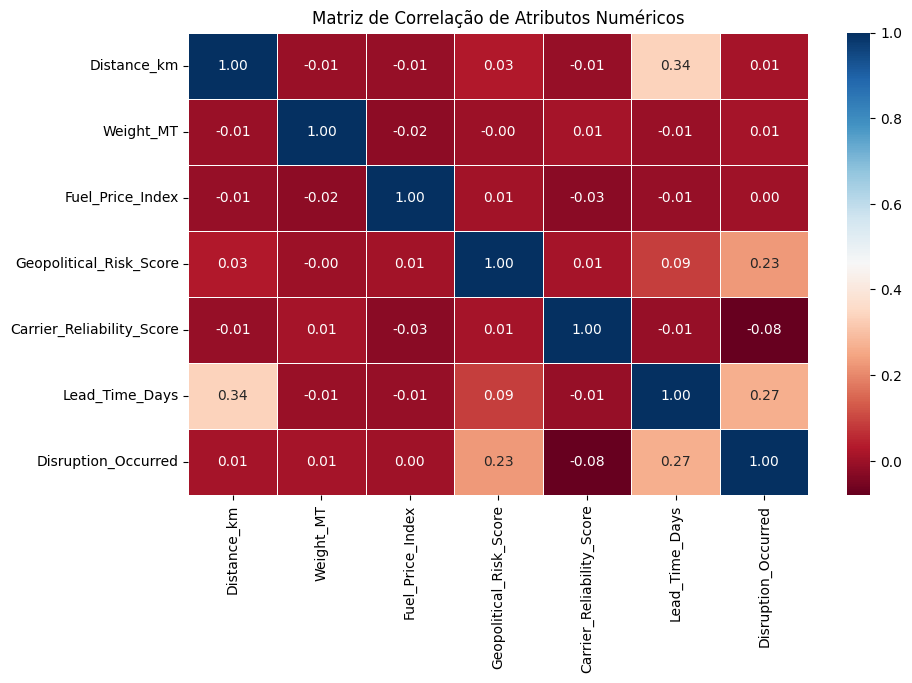

In [12]:

plt.figure(figsize=(10, 6))

# Removendo ID e datas para a correlação numérica
corr = df[colunas_numericas].corr()
sns.heatmap(corr, annot=True, cmap='RdBu', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação de Atributos Numéricos')
plt.show()

**Insights relevantes:**

Destaca-se a correlação positiva de **0.34** entre **`Distance_km`** e **`Lead_Time_Days`**, confirmando que a distância é um fator que mais impacta diretamente o tempo de entrega.

Outro ponto relevante é a correlação de **0.23** entre **`Geopolitical_Risk_Score`** e **`Disruption_Occurred`**, sugere que existe uma relação positiva, embora moderada, entre o risco geopolítico e a ocorrência de interrupções. Isso significa que, à medida que o risco geopolítico aumenta, a probabilidade de uma interrupção ocorrer na cadeia de suprimentos também tende a aumentar.

A ausência de correlações extremamente altas (acima de 0.8) entre variáveis independentes afasta o risco de multicolinearidade, garantindo estabilidade para futuros modelos de regressão ou classificação.

* **Verificando outliers (anomalias):**

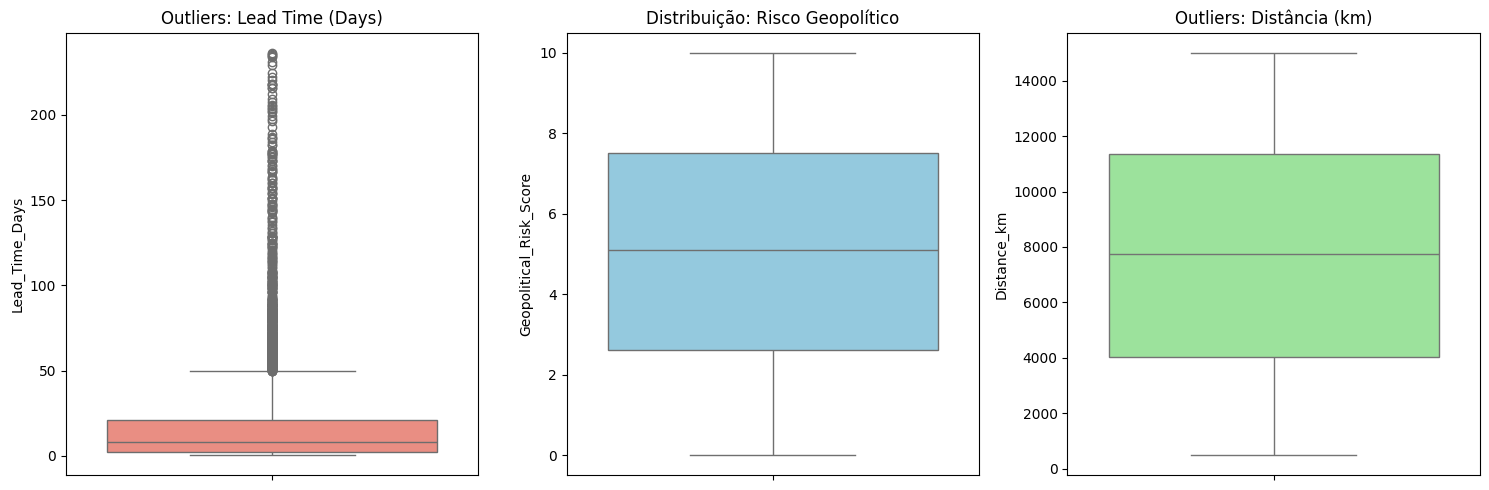

In [13]:

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Lead_Time_Days'], color='salmon')
plt.title('Outliers: Lead Time (Days)')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Geopolitical_Risk_Score'], color='skyblue')
plt.title('Distribuição: Risco Geopolítico')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Distance_km'], color='lightgreen')
plt.title('Outliers: Distância (km)')

plt.tight_layout()
plt.show()

**Insights interessantes:**

O boxplot de `Lead_Time_Days` apresenta uma forte assimetria positiva, com a mediana concentrada em valores baixos (entregas rápidas). No entanto, observa-se uma presença massiva de outliers superiores (eventos que ultrapassam 50 dias e chegam a 250 dias). Para empresas do setor de Óleo e Gás, esses pontos representam falhas críticas na cadeia de suprimentos que devem ser priorizadas, pois são casos onde o tempo de entrega saiu totalmente do controle operacional padrão.

* **Criando uma nova coluna para rankear a severidade de cada condição climática (`weather_condition`)**

In [14]:
# quais tipos de condicoes climaticas tem na coluna Weather_Condition
print("\nLista de valores únicos:")
print(df['Weather_Condition'].unique())


Lista de valores únicos:
['Hurricane' 'Storm' 'Rain' 'Fog' 'Clear']


In [15]:
# mantem a coluna original 'Weather_Condition' e cria a nova 'Weather_Severity_Rank'

mapping_clima = {
    'Clear': 1,
    'Rain': 2,
    'Fog': 3,
    'Storm': 3,
    'Hurricane': 4
}

# nova coluna de ranking
df['Weather_Severity_Rank'] = df['Weather_Condition'].map(mapping_clima)

# double check se a criaçao foi bem sucedida
print("Amostra dos dados com a nova coluna do ranking:")
display(df[['Weather_Condition', 'Weather_Severity_Rank']].head(10))

# media de Lead Time pelo ranking
print("\nLead Time médio por nível do ranking:")
display(df.groupby(['Weather_Condition', 'Weather_Severity_Rank'])['Lead_Time_Days'].mean())

print("\nO dataframe completo:")
df.head(10)

Amostra dos dados com a nova coluna do ranking:


,Weather_Condition,Weather_Severity_Rank
0,Hurricane,4
1,Storm,3
2,Rain,2
3,Hurricane,4
4,Fog,3
5,Rain,2
6,Storm,3
7,Fog,3
8,Clear,1
9,Storm,3



Lead Time médio por nível do ranking:


,,Lead_Time_Days
Weather_Condition,Weather_Severity_Rank,
Clear,1,6.698704
Fog,3,9.892847
Hurricane,4,53.501848
Rain,2,7.736049
Storm,3,19.299182



O dataframe completo:


,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Weather_Severity_Rank
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1,4
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1,3
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0,2
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1,4
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1,3
5,SC-10005,2024-08-16,Rotterdam,Marseille,Rail,Automotive,2761.92,44.98,4.06,2.2,Rain,0.869,2.16,1,2
6,SC-10006,2024-05-22,Shanghai,Antwerp,Rail,Pharmaceuticals,1342.21,388.62,1.31,2.6,Storm,0.981,2.99,0,3
7,SC-10007,2024-04-14,Busan,Antwerp,Air,Textiles,13059.55,423.93,3.32,5.7,Fog,0.558,1.25,1,3
8,SC-10008,2025-11-23,Dubai,Marseille,Air,Textiles,9216.17,91.73,3.72,5.0,Clear,0.855,0.62,1,1
9,SC-10009,2025-07-12,Los Angeles,Singapore,Rail,Electronics,10767.05,215.74,3.71,2.0,Storm,0.615,25.17,1,3


# **2. Análise Exploratória dos Dados**

###**2.1. Qual a taxa de interrupção geral?**

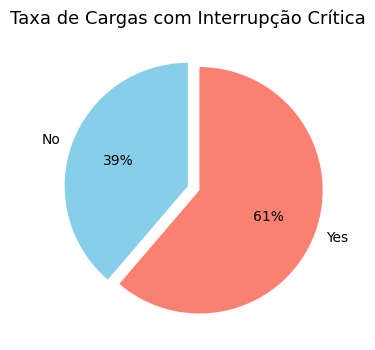

In [70]:
# 13. Taxa Global de Interrupções (Renomeado para Yes/No)
plt.figure(figsize=(4, 4))

# Agrupando e renomeando os índices para o gráfico
distribuicao_interrupcao = df.groupby('Disruption_Occurred').size()

distribuicao_interrupcao.index = distribuicao_interrupcao.index.map({0: 'No', 1: 'Yes'})

# Plotando o gráfico de pizza
distribuicao_interrupcao.plot.pie(
    autopct='%1.0f%%',
    colors=['skyblue', 'salmon'],
    startangle=90,
    explode=(0, 0.1)
)

plt.title('Taxa de Cargas com Interrupção Crítica', fontsize=13)
plt.ylabel('') # Remove o nome da coluna lateral
plt.show()

**Insights relevantes:**

Os dados revelam um cenário de alta instabilidade operacional. O índice de interrupções críticas atinge **61%** do volume total de cargas monitoradas, enquanto apenas **39%** das entregas seguem o fluxo planejado (*Perfect Order*) sem intercorrências.

Uma **taxa de interrupção superior a 60%** é considerada crítica para operações. Este dado justifica a necessidade de um mergulho profundo nas variáveis de **Clima, Geopolítica e Modal**, a fim de identificar se estas falhas são sistêmicas ou concentradas em gargalos específicos.

###**2.2. Qual modal impacta mais a media do tempo de entrega?**

In [18]:
# fixando cores de cada modal para clareza na visualizacao dos dados/graficos
cores_modal = {
    'Sea': '#103B53',   # azul
    'Rail': '#F1861A',  # laranja
    'Road': '#D53032',  # verde
    'Air': '#FCD55C'    # amarelo
}

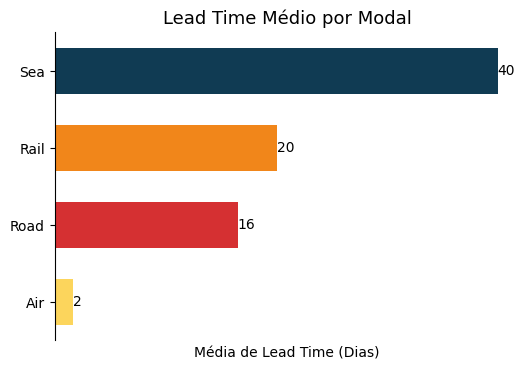

In [79]:
modal_mean = df.groupby('Transport_Mode')['Lead_Time_Days'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(6, 4)) # Ajustar o tamanho para um gráfico horizontal

sns.barplot(data=modal_mean, x='Lead_Time_Days', y='Transport_Mode', hue='Transport_Mode', palette=cores_modal, legend=False, saturation=1, width=0.6)

plt.title('Lead Time Médio por Modal', fontsize=13)
plt.xlabel('Média de Lead Time (Dias)')
plt.ylabel('') # Remover o rótulo do eixo Y, pois o modal será o rótulo da barra

# Adicionar rótulos de dados (Lead Time médio em dias) em cada barra
for index, row in modal_mean.iterrows():
    plt.text(row['Lead_Time_Days'], index, f"{row['Lead_Time_Days']:.0f}", color='black', ha="left", va="center") # Ajustar a posição para barras horizontais

plt.xticks([]) # Remover os ticks do eixo X

ax = plt.gca()

# Removendo bordas desnecessárias (spines)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.show()

**Insights relevantes:**

* **Modal Sea (Marítimo)**: Por percorrer as maiores distâncias e lidar com grandes volumes, apresenta o maior Lead Time médio (**40 dias**). Na prática, uma carga marítima leva, em média, **1 mês e 10 dias** para chegar ao destino final, o que exige um planejamento de estoque muito mais antecipado.

* **Modais Terrestres (Rail e Road)**: Ambos operam com um tempo de entrega inferior a um mês (**20 e 16 dias, respectivamente**). Comparados ao modal marítimo, possuem um Lead Time **50% e 60%,  respectivamente,** inferior, oferecendo uma agilidade intermediária para a malha logística.

* **Modal Air (Aéreo)**: É o modal de resposta imediata, levando apenas **2 dias** para a entrega final. Sendo o mais rápido entre os quatro analisados, ele se consolida como a via preferencial para itens de altíssima urgência, embora com as restrições de carga já mencionadas.

###**2.3. Qual é a probabilidade da carga extrapolar o LT Médio do modal dado ao Risco Geopolítico?**

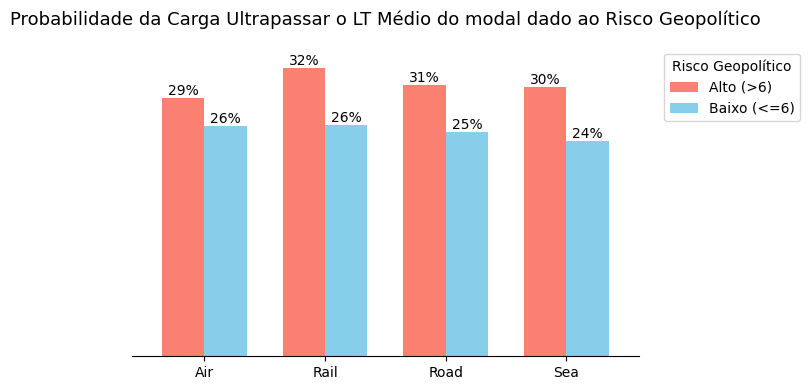

In [76]:
# 1. Calculando a média de Lead Time para CADA modal
medias_por_modal = df.groupby('Transport_Mode')['Lead_Time_Days'].mean()

# 2. Criando uma função para marcar o atraso relativo
def check_atraso_relativo(row):
    media_do_modal = medias_por_modal[row['Transport_Mode']]
    return 1 if row['Lead_Time_Days'] > media_do_modal else 0

df['Atraso_Relativo'] = df.apply(check_atraso_relativo, axis=1)

# 3. Preparando o gráfico comparativo
df['Risk_Level'] = df['Geopolitical_Risk_Score'].apply(lambda x: 'Baixo (<=6)' if x <= 6 else 'Alto (>6)')
grafico_dados = df.groupby(['Transport_Mode', 'Risk_Level'])['Atraso_Relativo'].mean().unstack() * 100

# 4. Plotando as Barras Agrupadas
ax = grafico_dados.plot(kind='bar', figsize=(7, 4), color=['salmon', 'skyblue'], width=0.7)

plt.title('Probabilidade da Carga Ultrapassar o LT Médio do modal dado ao Risco Geopolítico\n', fontsize=13)
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Risco Geopolítico', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.yticks([])
plt.ylabel('')

ax = plt.gca()

# Removendo bordas desnecessárias (spines)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Adicionar rótulos em cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='edge')

plt.tight_layout()
plt.show()

**Insights relevantes:**

* O modal **Air** é, evidentemente, o mais confiável em tempos de crise. O aumento na probabilidade de atraso é a menor entre os quatro (**11,5%**, saltando de 26% para 29%). Embora seja o modal mais seguro para manter a operação, sua capacidade é limitada pela impossibilidade técnica de transportar equipamentos de grande porte ou peso excessivo.

* Os modais **Road (24%) e Rail (23%)** apresentam as maiores taxas de vulnerabilidade operacional em tempos de clima geopolítico fica mais instável. Logo, cargas transportadas nestes modais tem rota com risco geopolitico > 6 devem possuir um estoque de segurança *(safety stock)* para suprir qualquer paralisão e evitar perdas na produção.

* O modal martimo, **Sea (25%)**, é o mais vulnerável entre os quatro, principalmente, em tempos de crise geopolitica. Como vemos atualmente no Oriente Médio onde o acesso restrito a pontos estratégicos, como o Estreito de Ormuz (Irã/Pérsia), transforma o risco geopolítico em paralisia operacional, retendo cargas por tempo indeterminado e elevando drasticamente o custo e a incerteza deste modal.


###**2.4. Qual o impacto real das condições climáticas (`Weather_Severity_Rank`) no atraso médio de cada modal?**




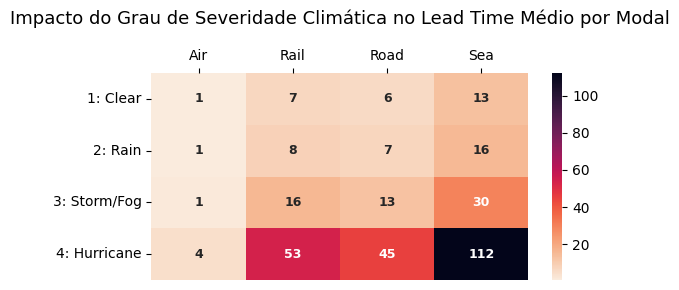

In [56]:
# Mapeamento para substituir números por nomes de forma clara
clima_nomes = {1: '1: Clear', 2: '2: Rain', 3: '3: Storm/Fog', 4: '4: Hurricane'}

# 1. Calculando a média de Lead Time e remodelando para o formato de tabela
# index = linhas (vertical), columns = colunas (horizontal)
df_clima_pivot = df.pivot_table(index='Weather_Severity_Rank',
                                columns='Transport_Mode',
                                values='Lead_Time_Days',
                                aggfunc='mean')

# Substituindo os códigos numéricos pelos nomes claros no índice (vertical)
df_clima_pivot.index = df_clima_pivot.index.map(clima_nomes)

# Garantindo que a ordem das linhas seja 1 (topo) a 4 (base) para lógica de tabela
df_clima_pivot = df_clima_pivot.reindex(['1: Clear', '2: Rain', '3: Storm/Fog', '4: Hurricane'])

plt.figure(figsize=(6, 3))


ax = sns.heatmap(df_clima_pivot,
                 annot=True, # annot=True: exibe os valores nas células
                 fmt=".0f",
                 cmap='rocket_r',
                 annot_kws={"size": 9, "weight": "bold"})

# títulos e Eixos (Ajustados para estilo de tabela)
plt.title('Impacto do Grau de Severidade Climática no Lead Time Médio por Modal\n', fontsize=13, pad=20)

# Colocando os rótulos do eixo X no topo (estilo cabeçalho de tabela)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Insights relevantes:**

* **Modal Air (Aéreo)**: Dentre os quatro modais, o aéreo é o mais resiliente sob a perspectiva climática. Observa-se que apenas em casos de severidade grau 4 (Hurricane) o modal sofre uma alteração significativa, aumentando o tempo médio de entrega (Lead Time) em **300%** (de **1 para 4 dias**).

* **Modal Rail (Ferroviário):** O impacto torna-se crítico a partir do grau 3 de severidade. Em cenários de nevoeiro (**Fog**) e furacão (**Hurricane**), o Lead Time aumenta drasticamente em **128%**(de 7 para 16) e **657%** (de 7 para 53), respectivamente, em relação às condições de céu limpo (Clear).

* **Modal Road (Rodoviário):** Este modal apresenta comportamento similar ao ferroviário. A partir do grau 3, o Lead Time médio aumenta **116%** (de 6 para 13) ao enfrentar situações de nevoeiro e **650%** (de 6 para 45) em condições extremas de furacão.

* **Modal Sea (Marítimo):** É o modal mais vulnerável a variações climáticas e janelas operacionais. Em situações de nevoeiro, o tempo médio de entrega cresce **131%** (de 13 para 30), enquanto em cenários de furacão, o impacto é severo, atingindo um aumento expressivo de **760%** (de 13 para 112) em relação a dias com condições climáticas favoráveis.


**Análise de Contingência Terrestre (Rail vs. Road):** A comparação entre os modais terrestres revela que o transporte rodoviário (**Road**) apresenta maior resiliência em cenários de crise, mantendo uma vantagem de **8 dias** (45 vs. 53 dias), isto é em média **18% mais ágil** em condições extremas de furacão (Hurricane) em relação ao ferroviário (**Rail**).

Essa diferença ocorre porque a malha ferroviária possui uma rigidez estrutural que impede desvios, enquanto o modal rodoviário permite rotas alternativas em caso de bloqueios físicos.

Portanto, o modal **Road** consolida-se como a principal alternativa de escape e redundância para cargas pesadas embora o **Rail** (ferroviário) seja eficiente em condições normais porém, a flexibilidade do caminhão deve ser levado em consideração para mitigar paralisias operacionais e garantir a continuidade do suprimento sob severidade climática.

###**2.5. Quão exposto o Lead Time médio de cada modal fica com o impacto do risco geopolítico?**

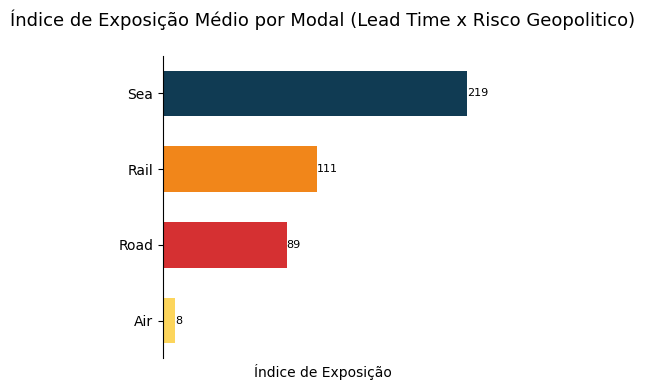

In [75]:
# Calculando a média do Índice de Exposição por Modal
df['Exposure_Index'] = df['Lead_Time_Days'] * df['Geopolitical_Risk_Score'] # a multiplicacao é utilizada porque o risco tem um efeito cumulativo sobre o tempo.

modal_exposure = df.groupby('Transport_Mode')['Exposure_Index'].mean().sort_values(ascending=False).reset_index()

# Visualização
plt.figure(figsize=(4, 4))
sns.barplot(data=modal_exposure, x='Exposure_Index', y='Transport_Mode', hue='Transport_Mode', palette=cores_modal, legend=False, saturation=1, width=0.6)

plt.title('Índice de Exposição Médio por Modal (Lead Time x Risco Geopolitico)\n', fontsize=13)
plt.xlabel('Índice de Exposição')
plt.ylabel('') # Remover o rótulo do eixo Y, pois o modal será o rótulo da barra

# Adicionando rótulos
for index, row in modal_exposure.iterrows():
    plt.text(row['Exposure_Index'], index, f'{row['Exposure_Index']:.0f}', color='black', ha='left', va='center', fontsize=8)

plt.xticks([]) # Remover os ticks do eixo X

ax = plt.gca()

# Removendo bordas desnecessárias (spines)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Insights relevantes:**

* O **modal aéreo (Air)**, com um índice residual de **8.5**, confirma sua posição não apenas como um modal rápido, mas como uma ferramenta de seguro operacional.

* O **modal marítimo (Sea)** apresenta um Índice de Exposição de **219.0**, o que é quase **26 vezes** maior que o **modal aéreo (Air)**. Isso demonstra que o frete marítimo carrega um custo oculto de exposição a riscos de atraso e incertezas geopolíticas extremamente elevado.

* Os modais **Rail e Road** operam em uma faixa de exposição intermediária (**89 e 110, respectivamente**). A diferença de **24%** sugere que, embora o ferroviário suporte mais carga, ele expõe a companhia a um risco de atraso ligeiramente superior ao rodoviário.

O índice de Exposição poderá ser utilizado para o cálculo de ***Safety Stock*** (estoque de segurança). Estipular um valor limite de exposição para cada modal (por ex. acima de 100 pontos) e exigem níveis de estoque mais agressivos para evitar a ruptura da linha de produção em caso de eventos geopolíticos.

###**2.6. Qual o impacto das interrupções (`Disruption_Occurred`) no Lead Time médio por modal?**

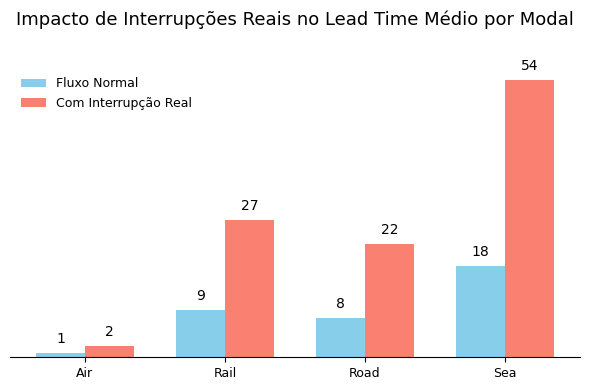

In [64]:
# Código para ver o impacto REAL das interrupções
disruption_impact = df.groupby(['Transport_Mode', 'Disruption_Occurred'])['Lead_Time_Days'].mean().unstack()


fig, ax = plt.subplots(figsize=(6, 4))
width = 0.35
x = np.arange(len(disruption_impact.index))

# Criando as barras
bar1 = ax.bar(x - width/2, disruption_impact[0], width, label='Fluxo Normal', color='skyblue')
bar2 = ax.bar(x + width/2, disruption_impact[1], width, label='Com Interrupção Real', color='salmon')

# 3. Adicionando os Rótulos (Data Labels) no topo das barras
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 pontos de deslocamento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

add_labels(bar1)
add_labels(bar2)

# 4. Ajustes de Estética (Storytelling)
ax.set_title('Impacto de Interrupções Reais no Lead Time Médio por Modal',
             fontsize=13, loc='center', pad=30)

# Removendo Escala e Labels do Eixo Y conforme solicitado
ax.set_yticks([])
ax.set_ylabel('')

# Ajustando o Eixo X
ax.set_xticks(x)
ax.set_xticklabels(disruption_impact.index, fontsize=9)

# Removendo bordas desnecessárias (spines)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

**Insights relevantes:**

Enquanto o risco geopolítico é uma probabilidade, o atributo `Disruption_Occurred` representa o evento já concretizado (bloqueios, greves ou falhas mecânicas). Esta análise revela o quão sensível cada modal se torna quando o fluxo planejado é interrompido:

> **Modal Air (Aéreo):**

* Apesar de **dobrar o tempo de entrega**, o impacto prático é de apenas **1 dia adicional**.

* Mesmo em cenários de colapso, o modal entrega o componente em até 48h. Isso o consolida como a única opção viável para peças de reposição crítica (spares) que mantêm a continuidade da operação.

> **Modais Terrestres (Rail & Road):**

* **Rail (Ferroviário)**: Apresenta a maior sensibilidade relativa junto com o marítimo (200%). Isso reflete a **rigidez da malha**: em caso de interrupção em um trecho, a ausência de rotas de fuga acaba por **triplicar** o tempo de espera (**9 para 27 dias**).

* **Road (Rodoviário)**: Embora sofra um aumento expressivo de **175%,** demonstra maior flexibilidade que o ferroviário (**22 vs 27 dias** no cenário de crise). Essa vantagem deve-se à capacidade de redirecionamento dinâmico que a malha rodoviária permite frente a bloqueios físicos.

> **Modal Sea (Marítimo):**

* Sofre um aumento drástico de **200%**, saltando de **18 para 54 dias**, sendo assim o modal mais sensível para a continuidade operacional.

* Um **atraso de 36 dias** (mais de um mês) em suprimentos de grande portepode desestruturar cronogramas inteiros e gerar multas contratuais pesadas. No modal marítimo, a interrupção deixa de ser um mero atraso e torna-se um gargalo crítico para a operação.


----


# **3. Considerações finais**

A partir do conhecimento da taxa de interrupção chega a **61%** e da análise do comportamento das variáveis climáticas, geopolíticas e operacionais no tempo de entrega dos suprimentos, as principais conclusões foram:

> **O modal maritimo (Sea):**

Embora inevitável para o transporte de grandes volumes, este é o gargalo central da cadeia. Com o maior tempo médio de entrega (LT = 40 dias), ele apresenta um Índice de Exposição **26 vezes** maior que o aéreo. Na prática, este modal é altamente vulnerável a crises como mostra o projeto que em cenários de eventos climáticos extremos (furacões) elevam o tempo médio de entrega do modal em até **760%**, e interrupções reais **triplicam** sua latência, *adicionando **36 dias** extras* ao cronograma. Este atraso residual é suficiente para paralisar operações e gerar multas severas.

> **Os modais terrestres (Road & Rail):**

Na comparação entre os modais terrestres, o caminhão (**Road**) consolida-se como a principal rota de escape frente ao trem (**Rail**). A rigidez estrutural da malha ferroviária impede desvios durante crises geopolíticas ou climáticas, fazendo com que o trem também **triplique** seu tempo médio de espera (Lead Time médio) sob interrupção. O modal **rodoviário (Road)**, por permitir redirecionamento dinâmico de rotas, absorve melhor o impacto e garante entregas até **18% mais ágeis** (*uma vantagem de **8 dias***) em cenários de intercorrência climática.

> **O modal Aéreo (Air):**

O transporte **aéreo (Air)** provou ser o único amortecedor confiável do sistema. Além de ser o mais rápido (**2 dias**), sua resiliência é incomparável dado que a pior interrupção possível adiciona apenas **1 dia** ao seu prazo final. Ele raramente tem as operações paralisadas por bloqueios geográficos e/ou severidade climática, justificando seu custo elevado como a via exclusiva para peças de reposição crítica.

Porém, assim como ocorre com o caminhão no modal **rodoviário (Road)**, o transporte aéreo usufrui da possibilidade de mudança de rota em situações de bloqueios aéreos temporários como vem acontecendo atualmente no Oriente Médio, uma das rotas mais movimentadas do mundo, dado ao conflito entre Irã (Pérsia) e Israel/Estados Unidos.

###**Conclusão e Plano de Ação**


A fim de reduzir a taxa de falhas, a estratégia de suprimentos é altamente aconselhável a adoção de políticas de **Safety Stock** (*estoque de segurança*) principalmente para os suprimentos transportados pelo modal **martimo (Sea)** dimensionadas pelo Índice de Exposição, e não apenas pela média histórica de entrega.

Cargas alocadas no modal **marítimo (Sea)** ou **ferroviário (Rail)** em rotas de alto risco geopolítico exigem margens de estoque mais agressivas, enquanto o modal **rodoviário (Road)** deve ser institucionalizado como a alternativa prioritária em casos extremos dado a sua flexibilidade de redirecionamento.
